In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import numpy
import pickle 
import ast
from collections.abc import Iterable
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import pairwise_distances

#import the modules for analyzing the results of the k-path search
from Path_Analytics import *
import glob
import os
from tqdm import tqdm

In [17]:
with open('../data_and_models/search_results_tree_k6_n5.pkl', 'rb') as f:
    check = pickle.load(f)

In [20]:
check

,search_id,type_of_search,n_steps,k,n_paths,beta,blend,threshold,starting_cl,target_cl,...,step,path_type,is_best_at_step,is_success,covered_threshold,end_position,drug_sequence,genes_targeted,cell_path,final_distance
0,10,k_path_tree,5,6,None,None,2,0.5,CVCL_0023,CVCL_0332,...,1.0,best_at_step,True,False,False,"[0.22140636999999996, 0.3578622, 0.5259334, -1...","[[('Abemaciclib', 5.0, 'uM')]]","[(cdk4, cdk6)]","[[CVCL_0023, None]]",8.152299
1,10,k_path_tree,5,6,None,None,2,0.5,CVCL_0023,CVCL_0332,...,2.0,best_at_step,True,False,False,"[0.6071244626156608, 0.383817179680112, -0.035...","[[('Abemaciclib', 5.0, 'uM')], [('(R)-Verapami...","[(cdk4, cdk6), (cacna1f, cacna1s, abcb1, cyp3a...","[[CVCL_0023, None], [CVCL_1716, CVCL_0023]]",7.989775
2,10,k_path_tree,5,6,None,None,2,0.5,CVCL_0023,CVCL_0332,...,3.0,best_at_step,True,False,False,"[0.7928175294447383, 0.39658612466823, -0.4000...","[[('Abemaciclib', 5.0, 'uM')], [('Terfenadine'...","[(cdk4, cdk6), (hrh1, kcnh2), (cacna1f, cacna1...","[[CVCL_0023, None], [CVCL_1716, CVCL_0023], [C...",8.044549
3,10,k_path_tree,5,6,None,None,2,0.5,CVCL_0023,CVCL_0332,...,4.0,best_at_step,True,False,False,"[0.47331020212557096, 0.3126513317296326, 0.21...","[[('Abemaciclib', 5.0, 'uM')], [('Larotrectini...","[(cdk4, cdk6), (ntrk1, ntrk2, ntrk3), (cacna1f...","[[CVCL_0023, None], [CVCL_1716, CVCL_0023], [C...",7.923564
4,10,k_path_tree,5,6,None,None,2,0.5,CVCL_0023,CVCL_0332,...,5.0,best_at_step,True,False,False,"[0.41122650770281066, 0.3860951762813487, 0.29...","[[('Abemaciclib', 5.0, 'uM')], [('Larotrectini...","[(cdk4, cdk6), (ntrk1, ntrk2, ntrk3), (cacna1f...","[[CVCL_0023, None], [CVCL_1716, CVCL_0023], [C...",7.978921
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76243,2254,k_path_tree,5,6,None,None,2,0.5,CVCL_C466,CVCL_1724,...,1.0,best_at_step,True,False,False,"[0.22615593999999994, 0.93932086, 1.5589155, 0...","[[('Bortezomib', 5.0, 'uM')]]","[(psmb1, psmd8, psmb7, psmd3, psma3, psmb3, ps...","[[CVCL_C466, None]]",6.651125
76244,2254,k_path_tree,5,6,None,None,2,0.5,CVCL_C466,CVCL_1724,...,2.0,best_at_step,True,False,False,"[-0.5010930965521725, 0.663907391526372, 1.519...","[[('vincristine', 5.0, 'uM')], [('olaparib', 5...","[(tubb1, tubb4b, tubb8, tuba3c, tuba1c, tubb2a...","[[CVCL_C466, None], [CVCL_C466, CVCL_1715]]",6.156743
76245,2254,k_path_tree,5,6,None,None,2,0.5,CVCL_C466,CVCL_1724,...,3.0,best_at_step,True,False,False,"[-0.3522973873770415, 0.5100059583947778, 1.03...","[[('vincristine', 5.0, 'uM')], [('olaparib', 5...","[(tubb1, tubb4b, tubb8, tuba3c, tuba1c, tubb2a...","[[CVCL_C466, None], [CVCL_C466, CVCL_1715], [C...",5.743894
76246,2254,k_path_tree,5,6,None,None,2,0.5,CVCL_C466,CVCL_1724,...,4.0,best_at_step,True,False,False,"[-0.4700949706864638, 0.2764936304438177, 0.90...","[[('vincristine', 5.0, 'uM')], [('olaparib', 5...","[(tubb1, tubb4b, tubb8, tuba3c, tuba1c, tubb2a...","[[CVCL_C466, None], [CVCL_C466, CVCL_1715], [C...",5.545217


In [28]:
check.groupby(['starting_cl', 'target_cl'])['type_of_search'].count().sort_values(ascending=False).iloc[:20]

starting_cl  target_cl
CVCL_1097    CVCL_0292    6456
CVCL_C466    CVCL_0292    6125
CVCL_1517    CVCL_0292    5286
CVCL_1125    CVCL_0292    4596
CVCL_0332    CVCL_0292    4585
CVCL_0334    CVCL_0292    4299
CVCL_1666    CVCL_0292    3775
CVCL_1094    CVCL_0292    3703
CVCL_0459    CVCL_0292    3206
CVCL_0504    CVCL_0292    3148
CVCL_0359    CVCL_0292    2935
CVCL_1715    CVCL_0292    2183
CVCL_0131    CVCL_0292    1804
CVCL_0366    CVCL_0292    1348
CVCL_1285    CVCL_0292    1210
CVCL_1097    CVCL_1716    1106
CVCL_1731    CVCL_0292     921
CVCL_0069    CVCL_0292     874
CVCL_0399    CVCL_0292     706
CVCL_1381    CVCL_0292     670
Name: type_of_search, dtype: int64

In [2]:
with open('../data_and_models/algo_times.csv', 'r') as f:
    algo_times = pd.read_csv(f, index_col=0)

In [7]:
algo_times

,time,k,n_steps,strategy,n_paths
0,83.40,20.0,5,k_path_beam,NaN
1,195.20,40.0,5,k_path_beam,NaN
2,263.76,60.0,5,k_path_beam,NaN
3,267.34,80.0,5,k_path_beam,NaN
4,345.28,100.0,5,k_path_beam,NaN
5,380.57,120.0,5,k_path_beam,NaN
6,401.07,140.0,5,k_path_beam,NaN
7,448.07,160.0,5,k_path_beam,NaN
8,485.15,180.0,5,k_path_beam,NaN
9,503.68,190.0,5,k_path_beam,NaN


Goal: Create a set of analytics functions for the output of identified paths 
-
0) create a binary matrix of rows of paths and columns of drugs 
1) Distribution of drugs in each successful path across all conversions
2) Total number of successful paths for each conversion 
3) Unsupervised clustering for each conversion 
    - redundancy - total paths for each cluster 
    - uniqueness - total number of clusters per conversion 

#implement nearest neighbor and TSNE and UMAP

Jaccard Distance Threshold with Heirarchical clustering
-
option: Try different similarity parameters to ensure robust clustering

Meaning:
- 0.1 - 0.3 = Only paths with almost identical drug sets merge.
- 0.4 - 0.6 = Paths must share a fair proportion of drugs; moderate strictness
- 0.7 - 0.9 = Paths that share just a handful of drugs can end up together; coarse granularity
- 0.9 - 1.0 = Nearly everything collapses into one cluster (unless totally disjoint)

# Inside algorithms scaling analysis

In [3]:
with open('../data_and_models/algo_times.csv', 'r') as f:
    algo_times = pd.read_csv(f, index_col=0)

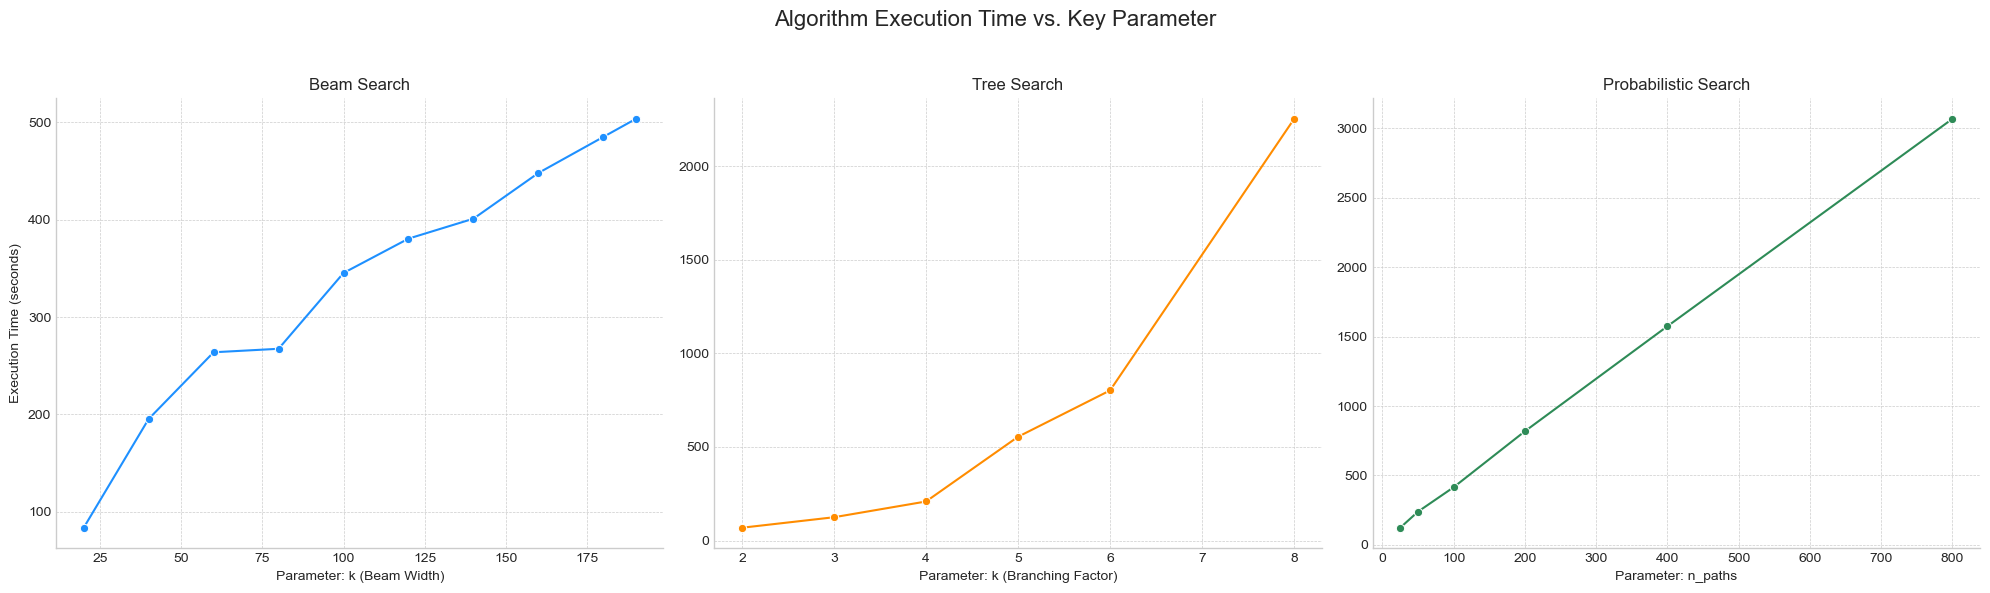

In [4]:
# Set a nice style for the plots
plt.style.use('seaborn-v0_8-whitegrid')

# Create a figure with 3 subplots, one for each strategy
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Algorithm Execution Time vs. Key Parameter', fontsize=16)

# --- Plot 1: k_path_beam ---
beam_df = algo_times[algo_times['strategy'] == 'k_path_beam']
sns.lineplot(data=beam_df, x='k', y='time', marker='o', ax=axes[0], color='dodgerblue')
axes[0].set_title('Beam Search')
axes[0].set_xlabel('Parameter: k (Beam Width)')
axes[0].set_ylabel('Execution Time (seconds)')

# --- Plot 2: k_path_tree ---
tree_df = algo_times[algo_times['strategy'] == 'k_path_tree']
sns.lineplot(data=tree_df, x='k', y='time', marker='o', ax=axes[1], color='darkorange')
axes[1].set_title('Tree Search')
axes[1].set_xlabel('Parameter: k (Branching Factor)')
axes[1].set_ylabel('') # Hide y-label for cleaner look

# --- Plot 3: prob (Probabilistic Search) ---
prob_df = algo_times[algo_times['strategy'] == 'prob']
sns.lineplot(data=prob_df, x='n_paths', y='time', marker='o', ax=axes[2], color='seagreen')
axes[2].set_title('Probabilistic Search')
axes[2].set_xlabel('Parameter: n_paths')
axes[2].set_ylabel('') # Hide y-label for cleaner look

# General adjustments
for ax in axes:
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Analyzing files: 100%|██████████| 6/6 [05:46<00:00, 57.73s/it] 


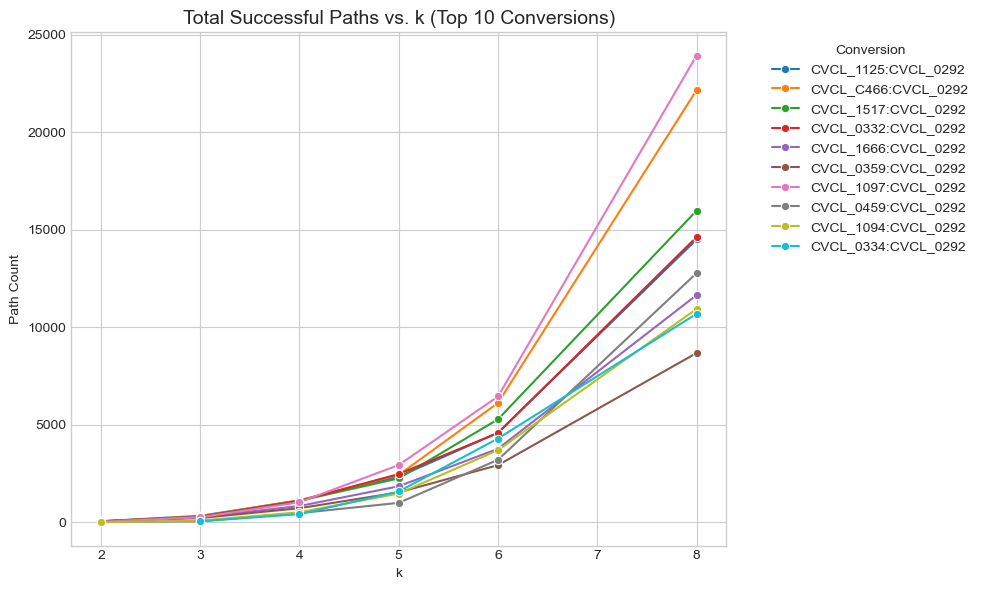

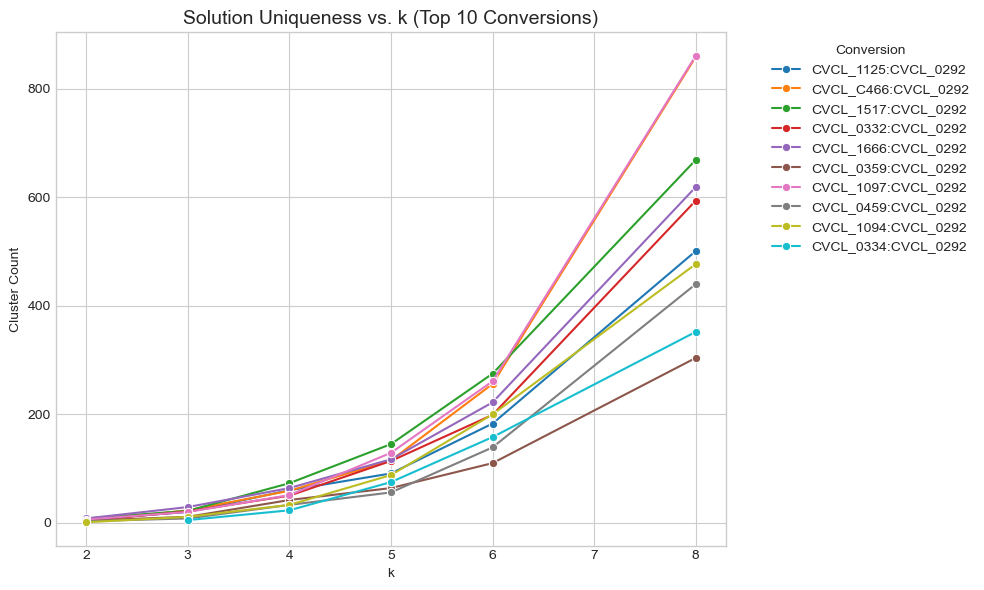

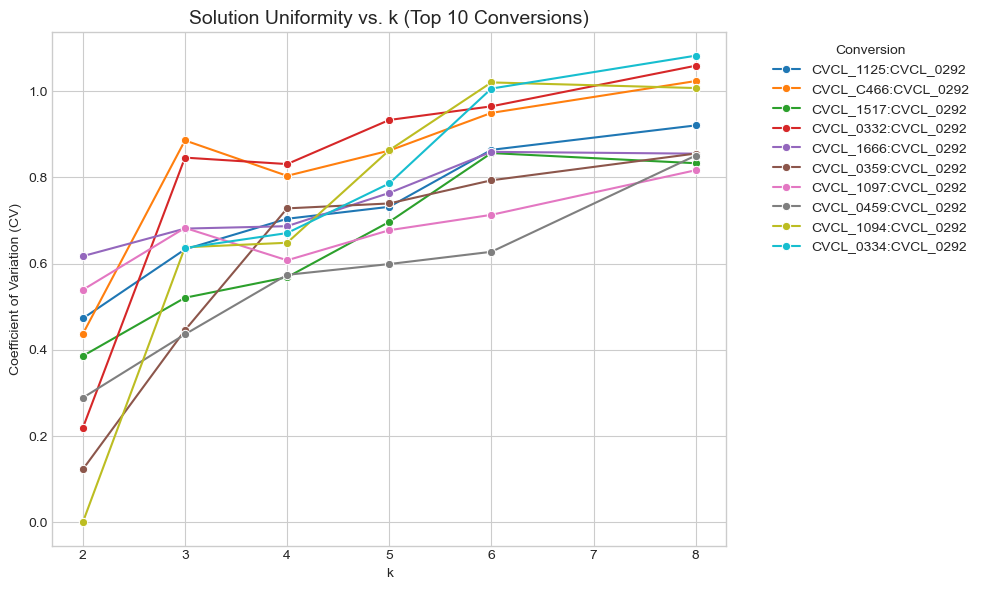

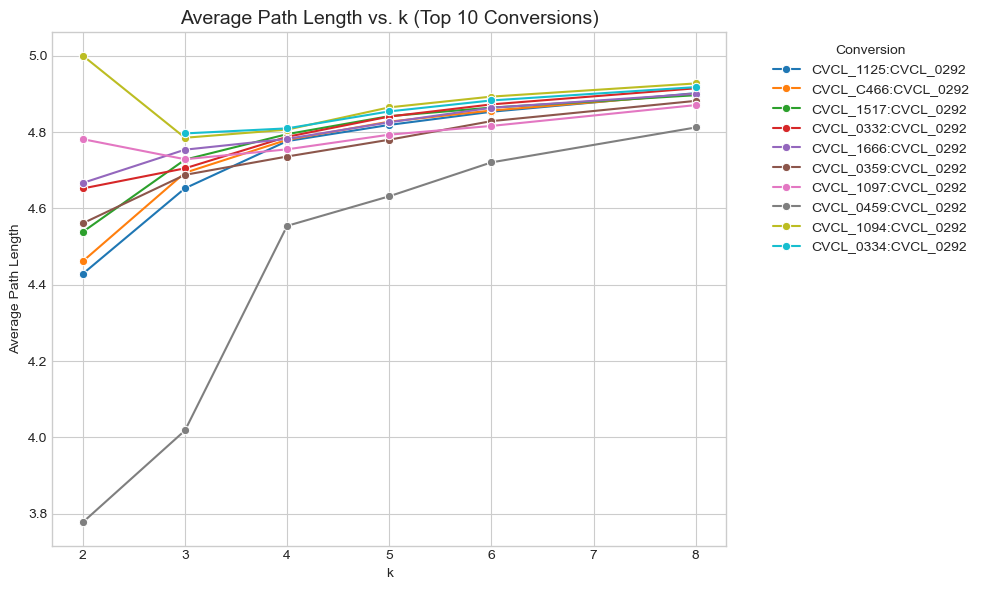

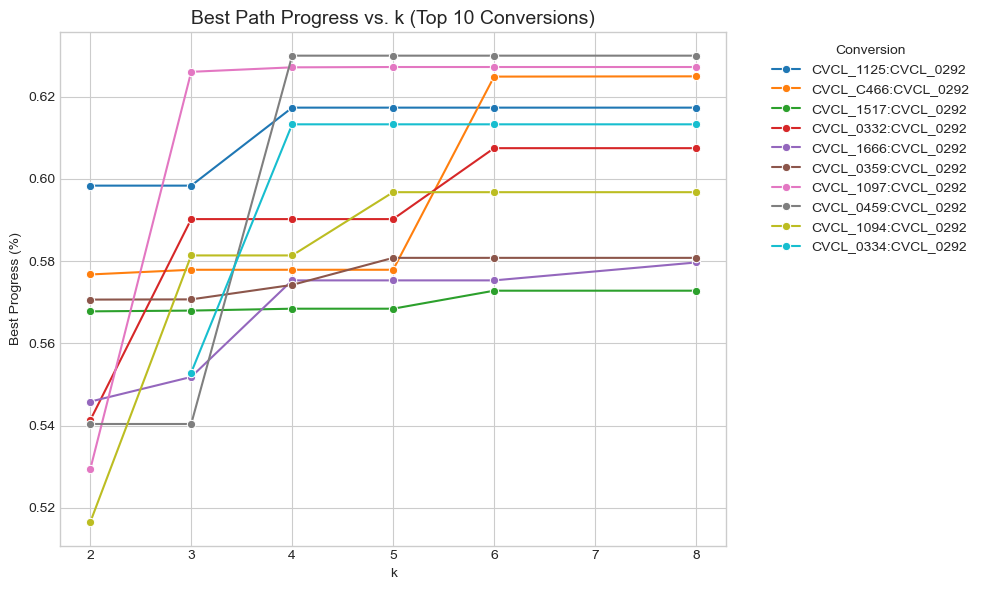

In [5]:
# --- 1. Find the result files ---
file_pattern = '../data_and_models/search_results_tree_k*_n5.pkl'
files_to_analyze = glob.glob(file_pattern)

# --- 2. Define the parameter name and the regex ---
param_name = 'k'
param_regex = r'_k(\d+)_'

# --- 3. Run the analysis ---
if files_to_analyze:
    # UPDATED: We only unpack one variable (the DataFrame) 
    # as the function now handles the multiple plots internally.
    results_summary = plot_per_conversion_trends(
        file_paths=files_to_analyze,
        param_name=param_name,
        param_regex=param_regex,
        top_n=10 
    )
else:
    print(f"No files found matching the pattern: {file_pattern}")

the more you search the less uniformity across clusters you get, the more you run it the more paths and clusters you get but these clusters become less uniform suggesting that even after running this not for too much we already get some sort of conversion to specific clusters. Makes sense from a biological pow (you would expect that to convert between one cell and another the actual conversion set is small). Further analysis could be: take one conversion (say the green one), consider top 10 cluster and plot over parameter the absolute number of paths per each cluster to then get to the conclusion to the decision of applying a drug set from a specific cluster. Also another thing I could do is to take one specific conversion and show that as we increase threhold we get less clusters and less uniform clusters (might not be true the last point). Also consider how this is in line with the fact that as you get closer, the % of random vectors of magnitude 1 that get you even closer is decreasing

Analyzing files: 100%|██████████| 10/10 [00:30<00:00,  3.04s/it]


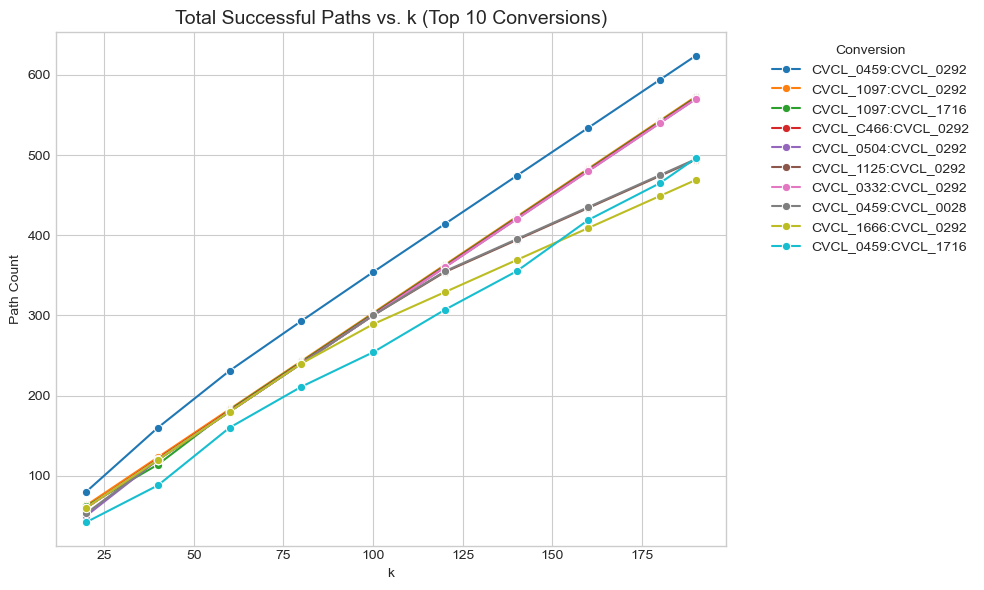

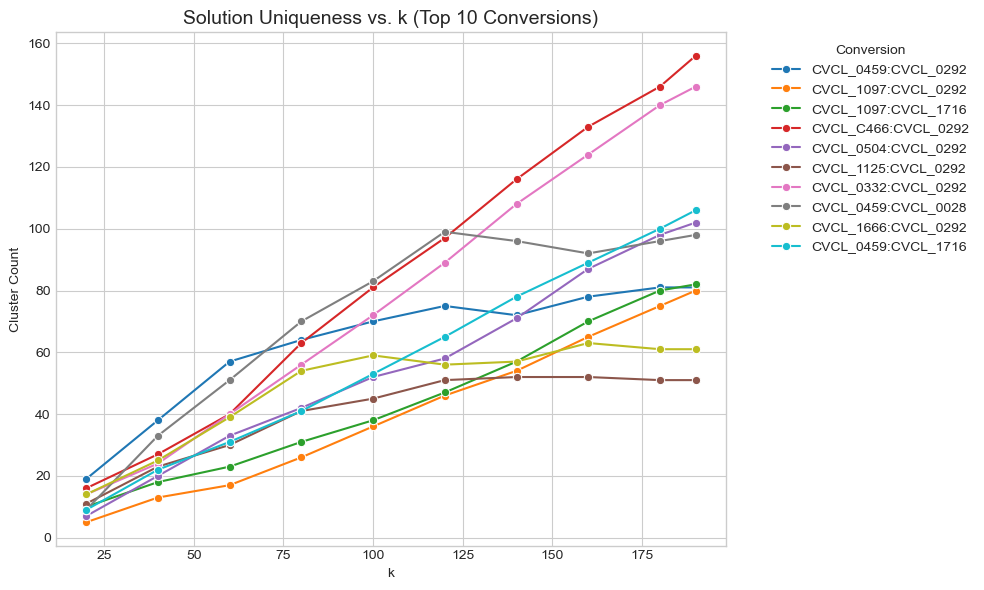

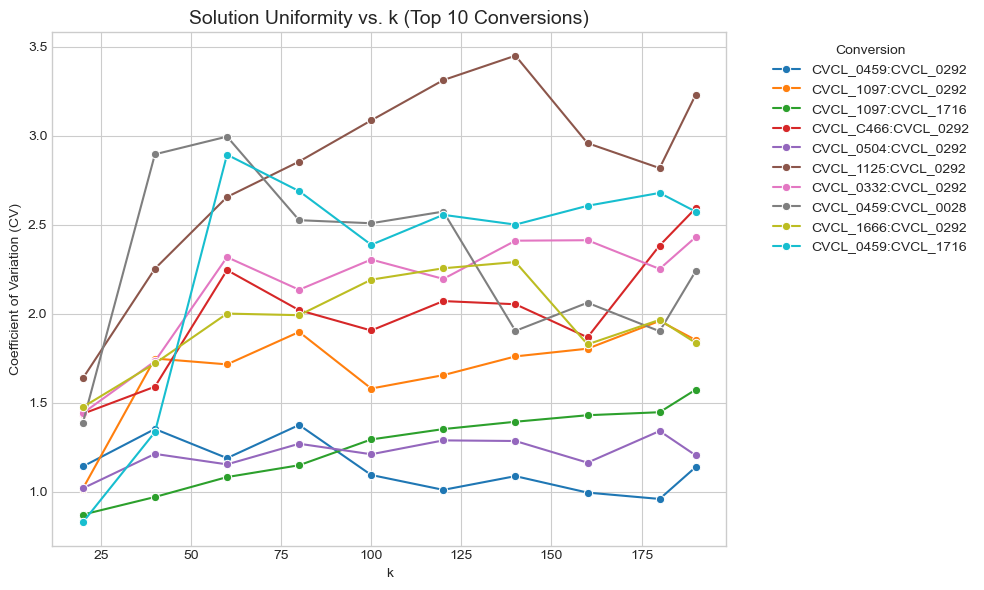

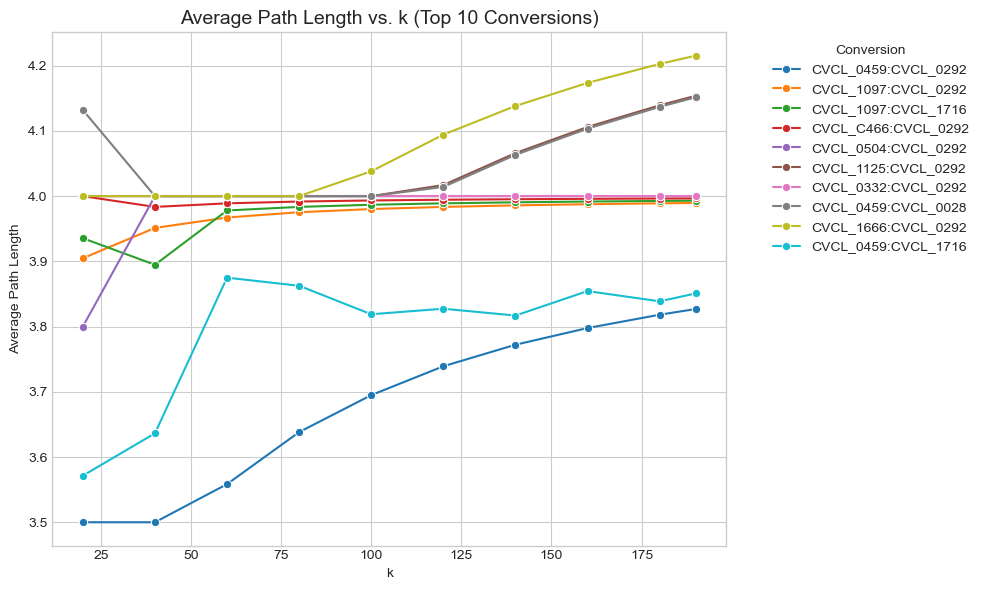

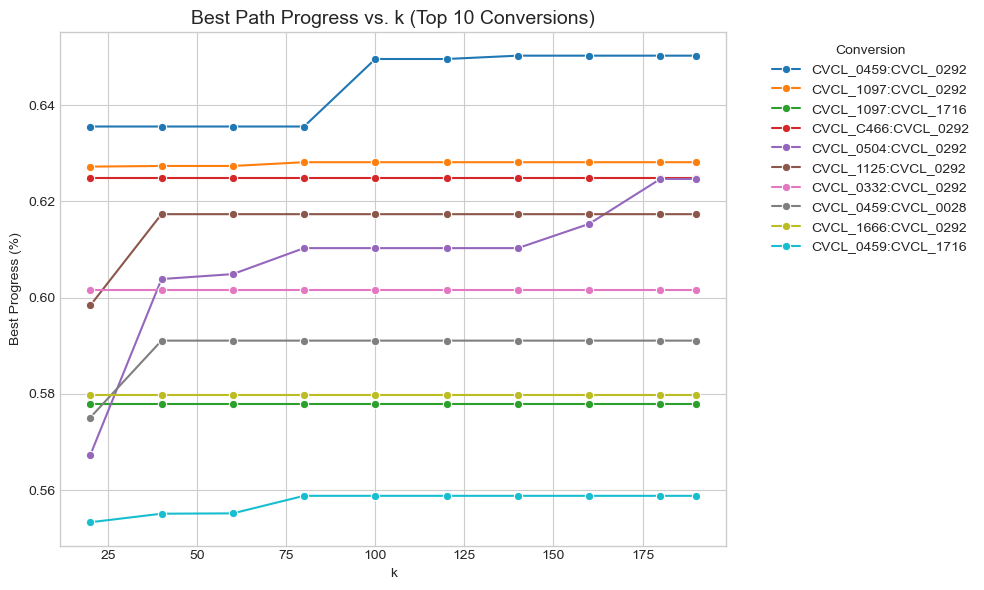

In [6]:
# This assumes the files are in the current directory.
# If they are in a subdirectory, add the path (e.g., 'data_and_models/search_*')
file_pattern = '../data_and_models/search_results_beam_k*_n5.pkl'
files_to_analyze = glob.glob(file_pattern)

# --- 2. Define the parameter name and the regex ---
# The parameter you varied is 'k'.
# The regex r'_k(\d+)_' finds the number between '_k' and '_'.
param_name = 'k'
param_regex = r'_k(\d+)_'

# --- 3. Run the analysis ---
if files_to_analyze:
    results_summary = plot_per_conversion_trends(
        file_paths=files_to_analyze,
        param_name=param_name,
        param_regex=param_regex,
        top_n=10 # You can adjust how many top conversions to show
    )
else:
    print(f"No files found matching the pattern: {file_pattern}")

Some analysis it could be done: is to understand whether if we divide for instance all the conversions into two sets, the ones that plateu (in terms of number of clusters) after some computea and the ones that keep increasing, and see whether there is some common characteristics in the two groups. Just use a metric calculating plateuness anf choose a threshold.

Analyzing files: 100%|██████████| 6/6 [00:00<00:00,  8.53it/s]


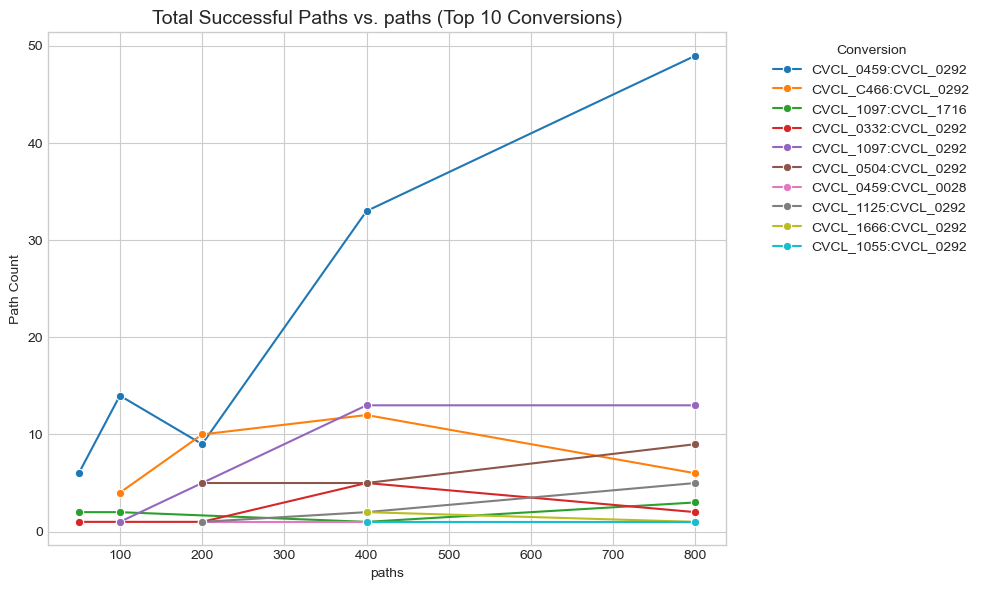

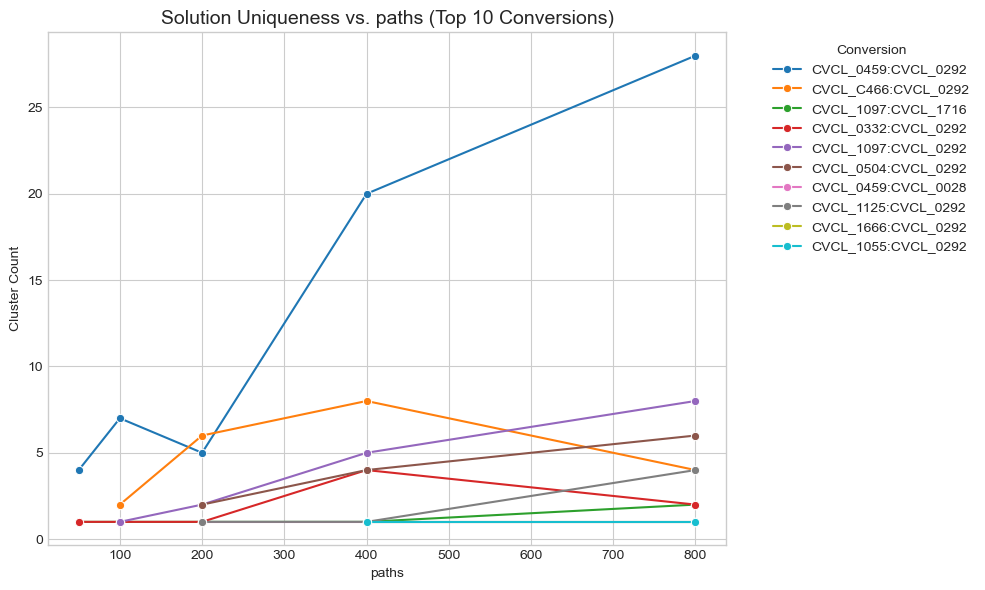

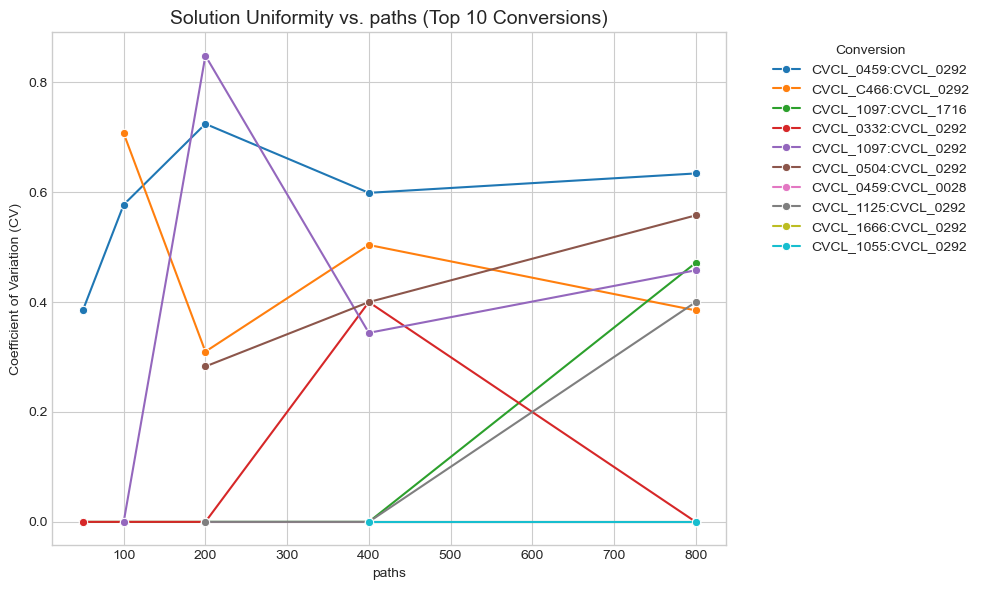

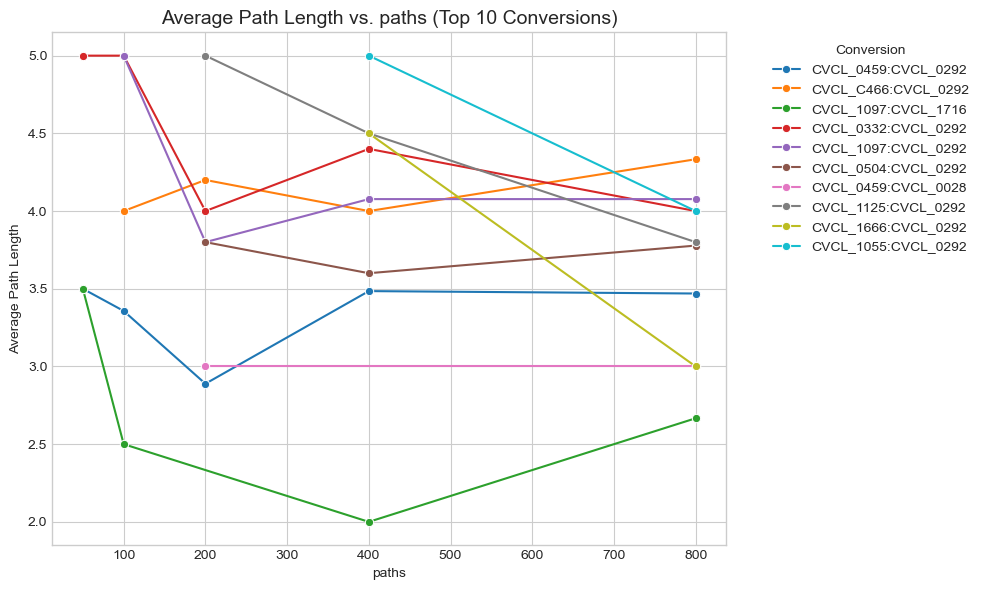

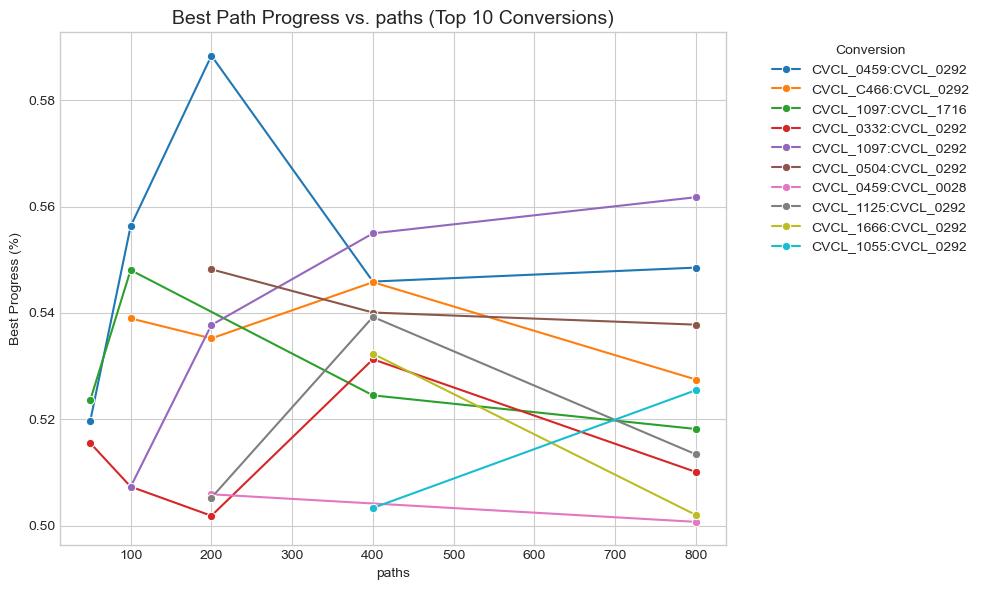

In [7]:
# This assumes the files are in the current directory.
# If they are in a subdirectory, add the path (e.g., 'data_and_models/search_*')
file_pattern = '../data_and_models/probabilistic_search_results_paths*_steps5.pkl'
files_to_analyze = glob.glob(file_pattern)

# --- 2. Define the parameter name and the regex ---
# The parameter you varied is 'k'.
# The regex r'_k(\d+)_' finds the number between '_k' and '_'.
param_name = 'paths'
param_regex = r'_paths(\d+)_'

# --- 3. Run the analysis ---
if files_to_analyze:
    results_summary = plot_per_conversion_trends(
        file_paths=files_to_analyze,
        param_name=param_name,
        param_regex=param_regex,
        top_n=10 # You can adjust how many top conversions to show
    )
else:
    print(f"No files found matching the pattern: {file_pattern}")

Analyzing files: 100%|██████████| 6/6 [05:33<00:00, 55.64s/it] 


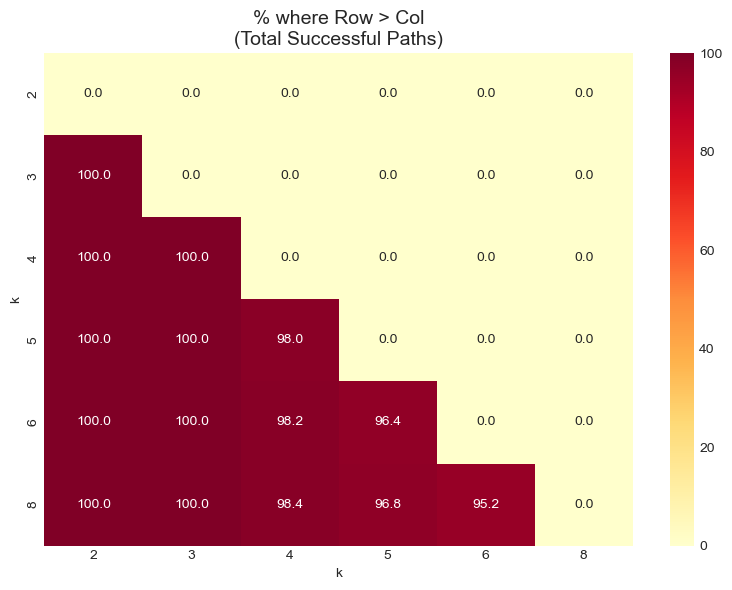

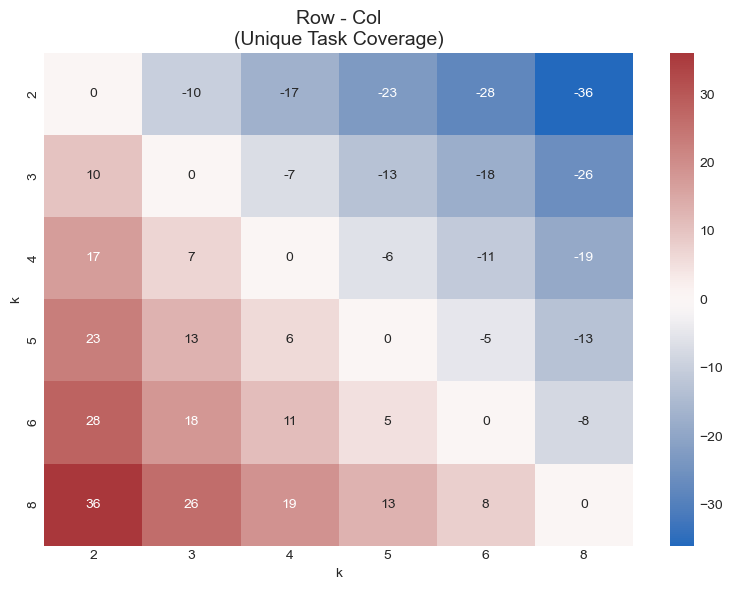

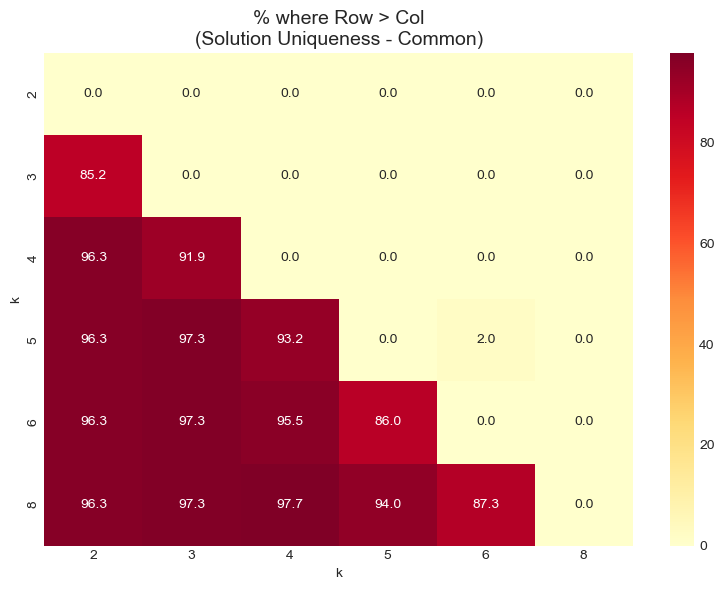

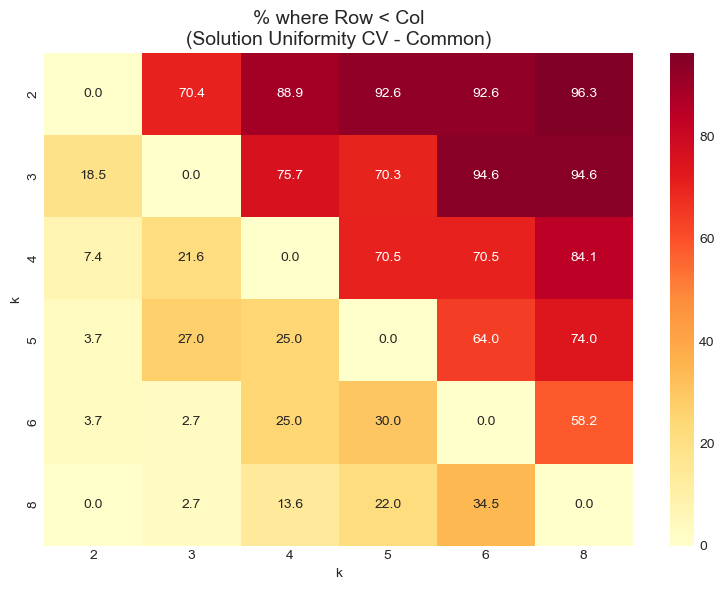

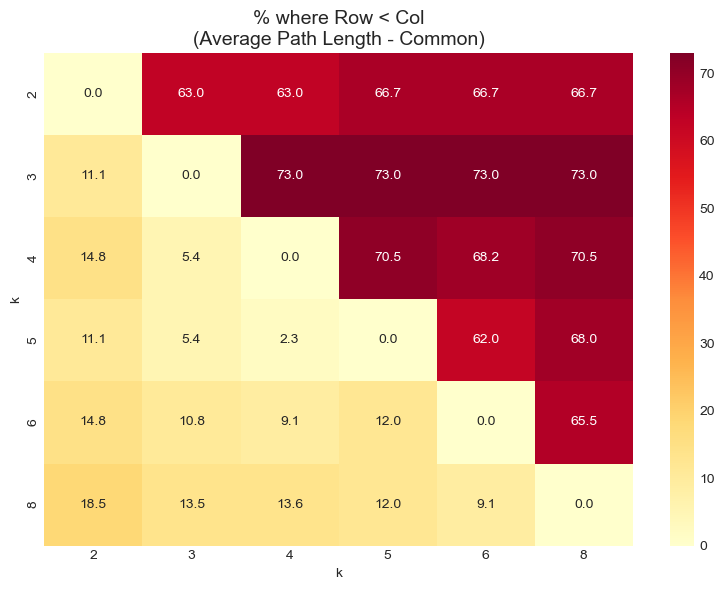

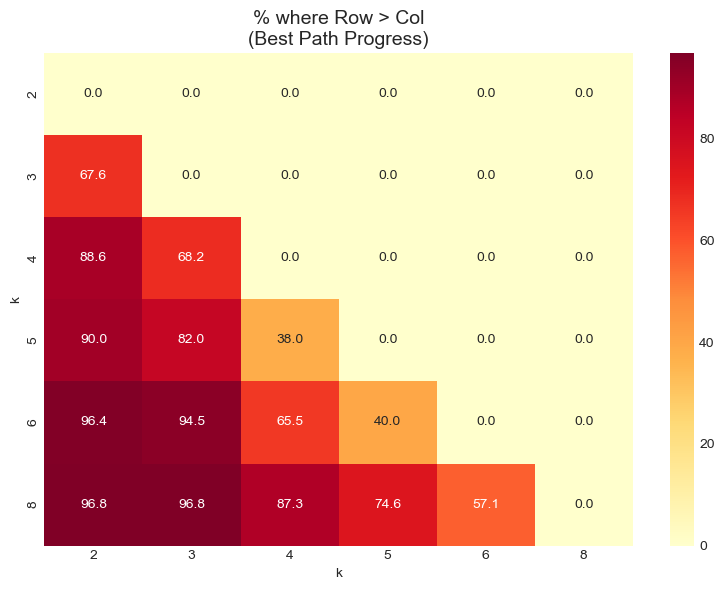

In [8]:
# This assumes the files are in the current directory.
# If they are in a subdirectory, add the path (e.g., 'data_and_models/search_*')
file_pattern = '../data_and_models/search_results_tree_k*_n5.pkl'
files_to_analyze = glob.glob(file_pattern)

# --- 2. Define the parameter name and the regex ---
# The parameter you varied is 'k'.
# The regex r'_k(\d+)_' finds the number between '_k' and '_'.
param_name = 'k'
param_regex = r'_k(\d+)_'

# --- 3. Run the analysis ---
if files_to_analyze:
    results_summary = plot_pairwise_parameter_comparison(
        file_paths=files_to_analyze,
        param_name=param_name,
        param_regex=param_regex
    )
else:
    print(f"No files found matching the pattern: {file_pattern}")

Analyzing files: 100%|██████████| 10/10 [00:30<00:00,  3.01s/it]


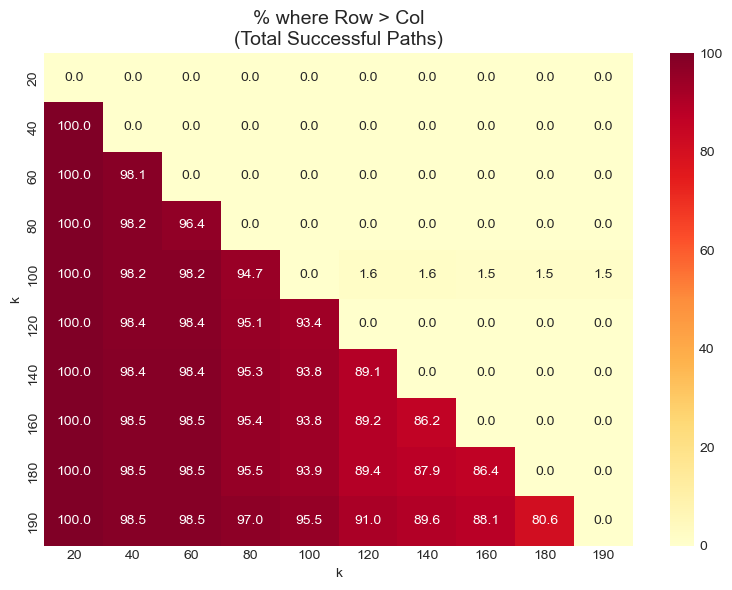

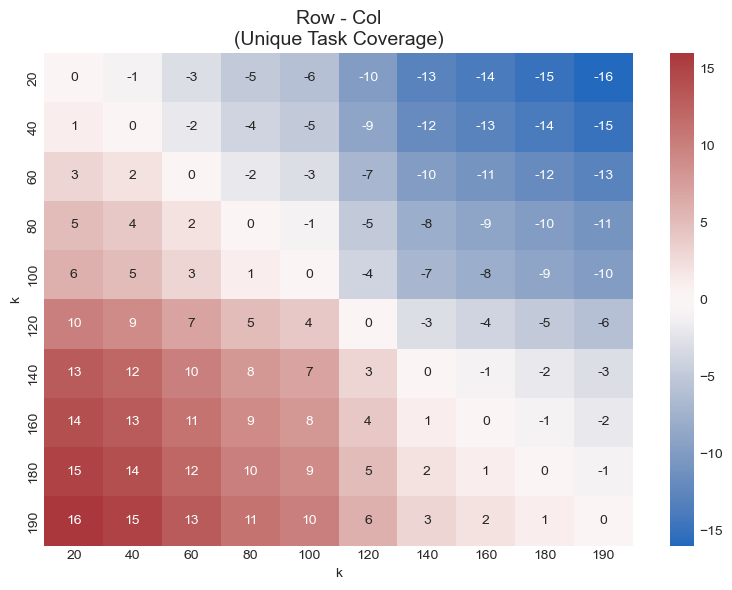

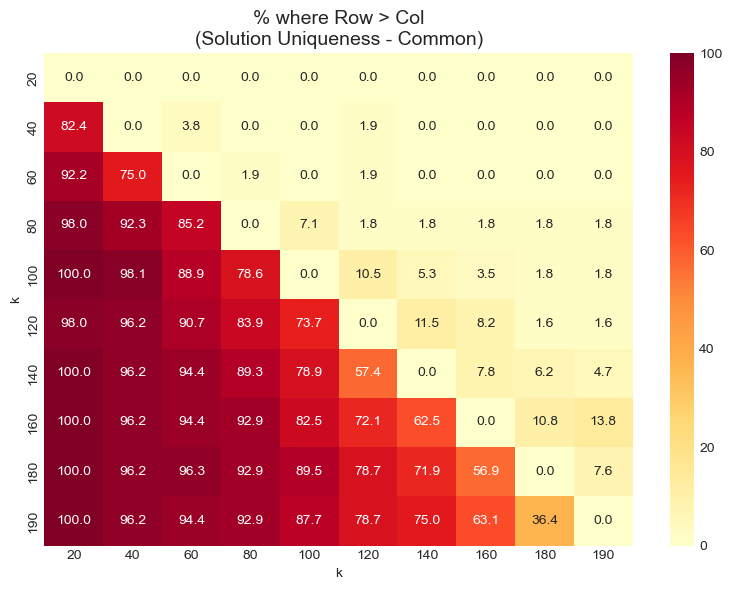

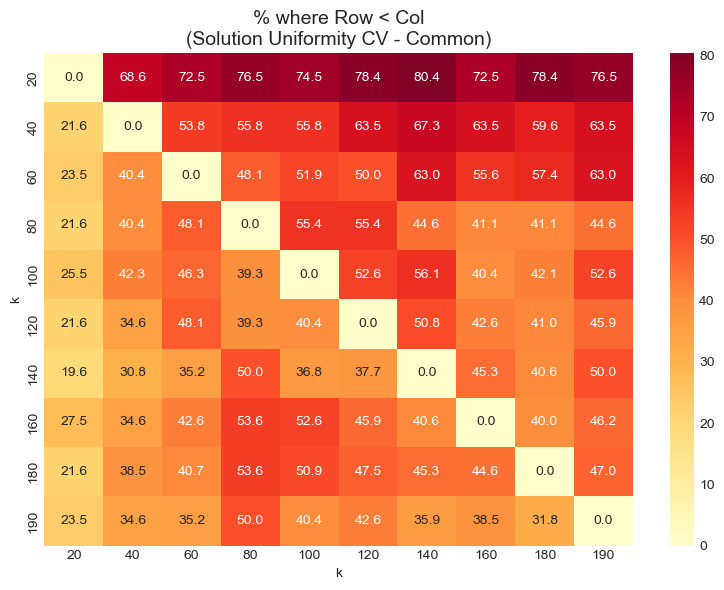

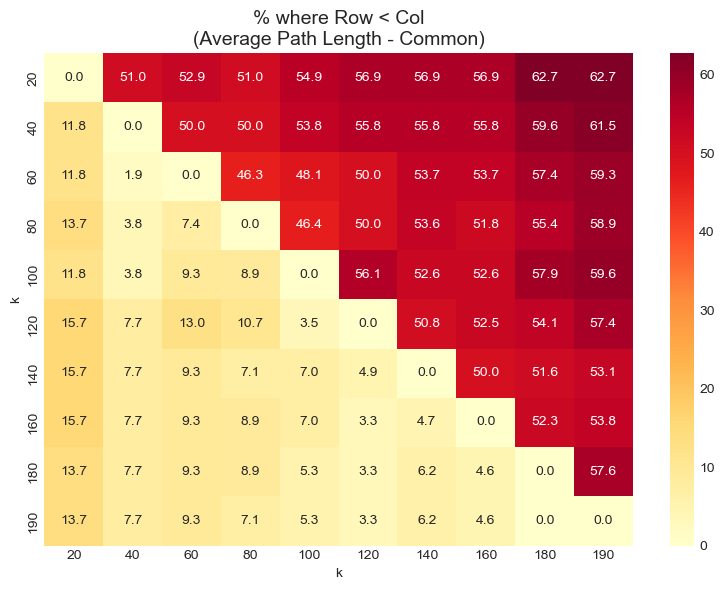

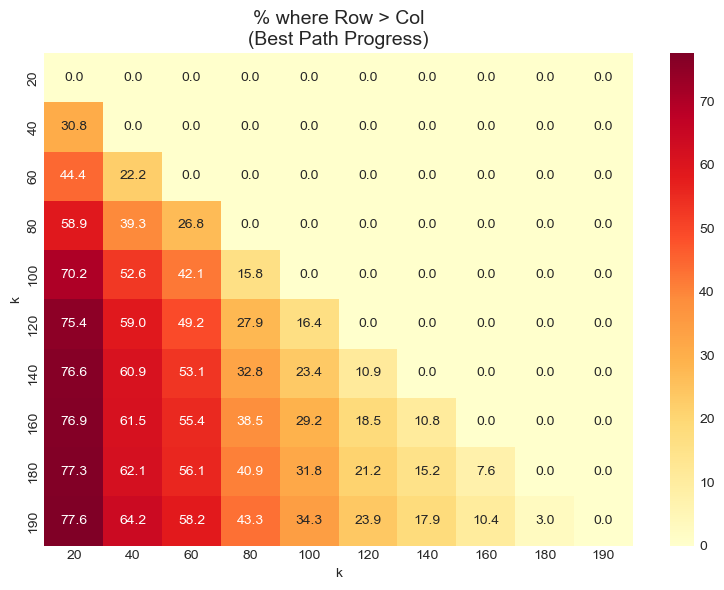

In [9]:
# This assumes the files are in the current directory.
# If they are in a subdirectory, add the path (e.g., 'data_and_models/search_*')
file_pattern = '../data_and_models/search_results_beam_k*_n5.pkl'
files_to_analyze = glob.glob(file_pattern)

# --- 2. Define the parameter name and the regex ---
# The parameter you varied is 'k'.
# The regex r'_k(\d+)_' finds the number between '_k' and '_'.
param_name = 'k'
param_regex = r'_k(\d+)_'

# --- 3. Run the analysis ---
if files_to_analyze:
    results_summary = plot_pairwise_parameter_comparison(
        file_paths=files_to_analyze,
        param_name=param_name,
        param_regex=param_regex
    )
else:
    print(f"No files found matching the pattern: {file_pattern}")

Analyzing files: 100%|██████████| 6/6 [00:00<00:00,  8.25it/s]


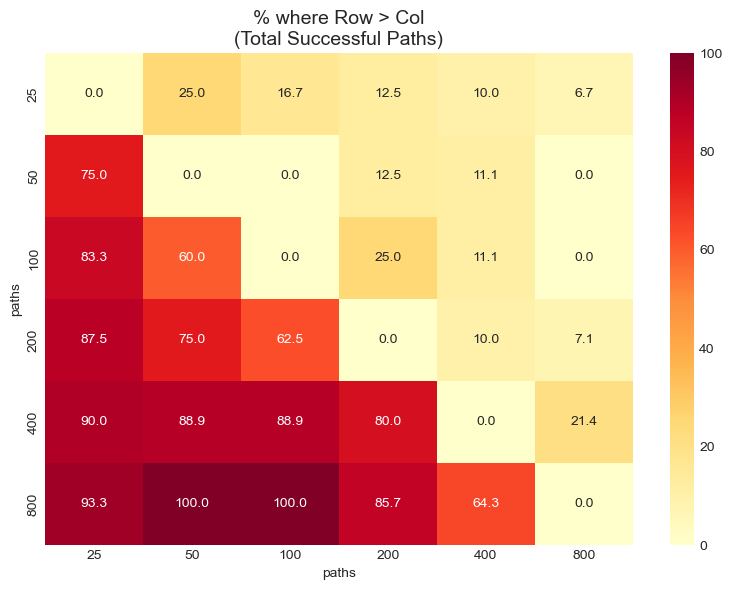

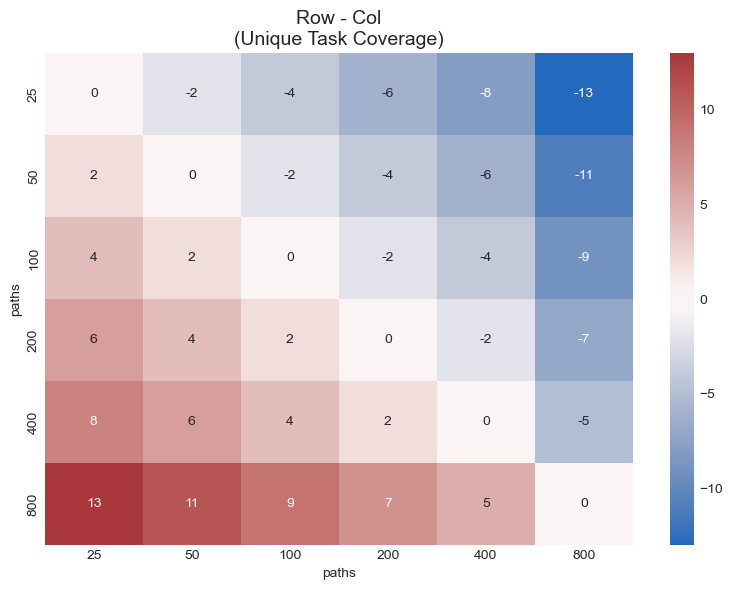

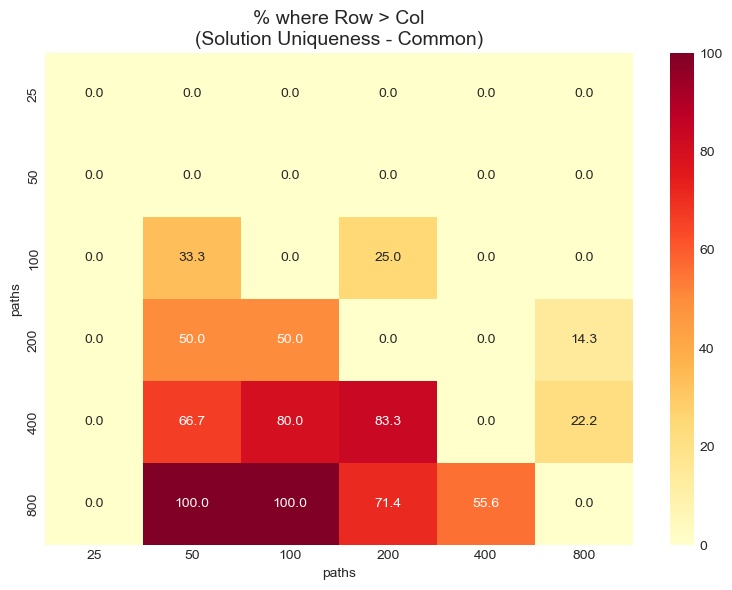

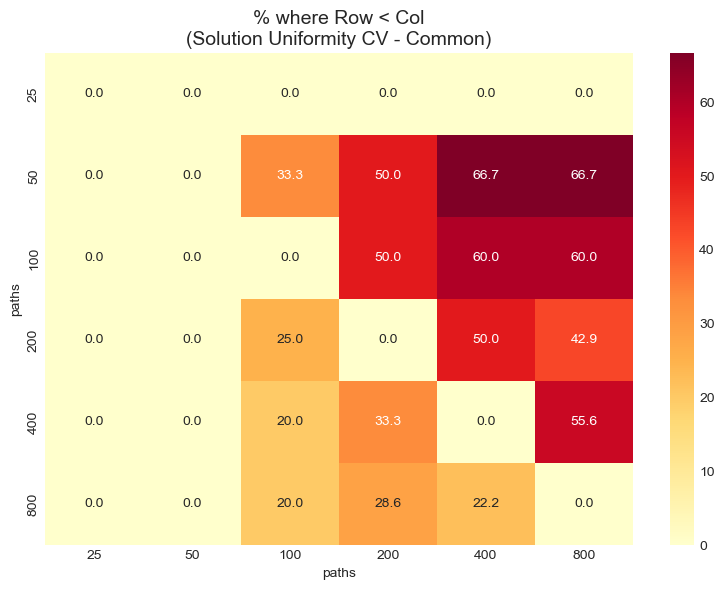

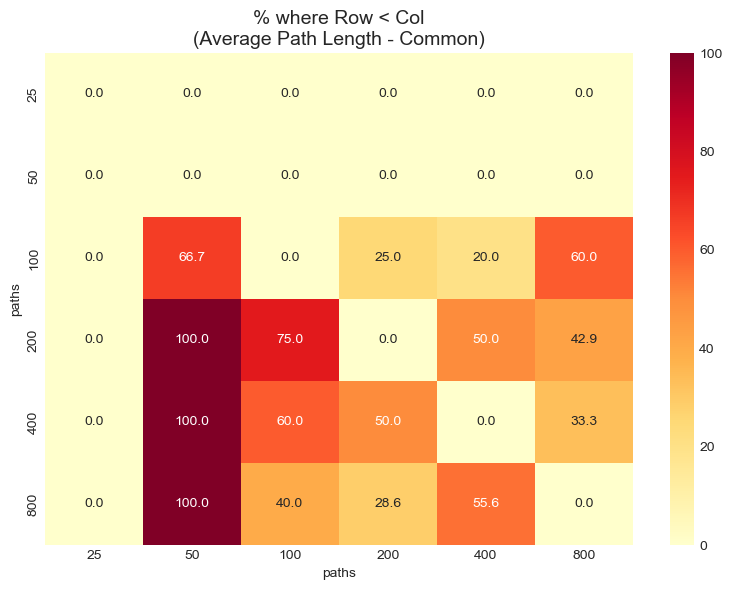

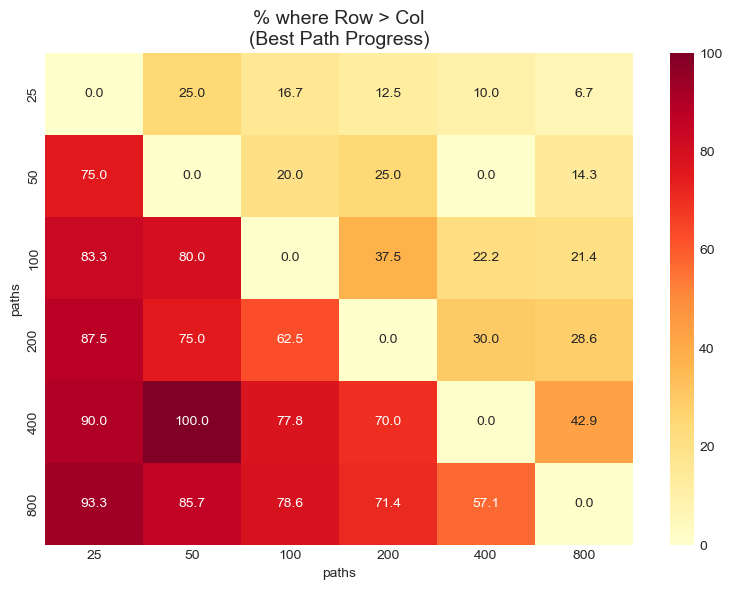

In [10]:
# This assumes the files are in the current directory.
# If they are in a subdirectory, add the path (e.g., 'data_and_models/search_*')
file_pattern = '../data_and_models/probabilistic_search_results_paths*_steps5.pkl'
files_to_analyze = glob.glob(file_pattern)

# --- 2. Define the parameter name and the regex ---
# The parameter you varied is 'k'.
# The regex r'_k(\d+)_' finds the number between '_k' and '_'.
param_name = 'paths'
param_regex = r'_paths(\d+)_'

# --- 3. Run the analysis ---
if files_to_analyze:
    results_summary = plot_pairwise_parameter_comparison(
        file_paths=files_to_analyze,
        param_name=param_name,
        param_regex=param_regex
    )
else:
    print(f"No files found matching the pattern: {file_pattern}")

# Across algorithms performance analysis

Calculating metrics: 100%|██████████| 22/22 [06:06<00:00, 16.67s/it]  


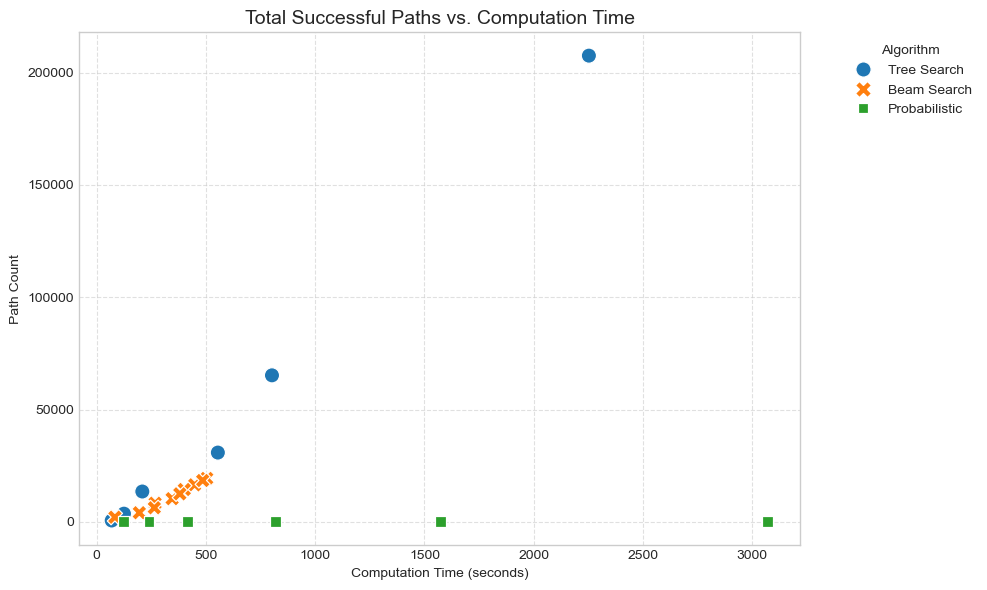

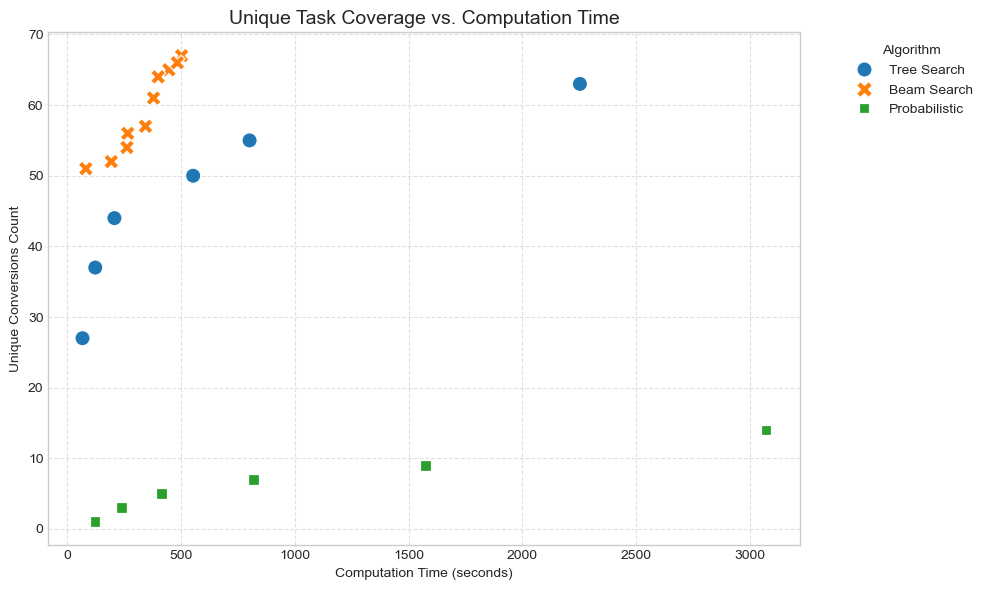

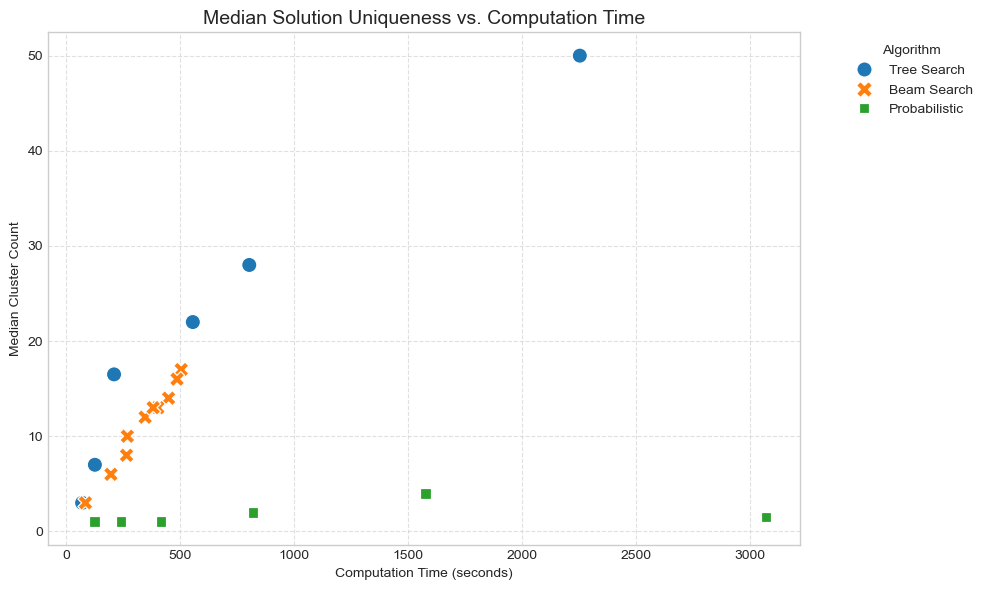

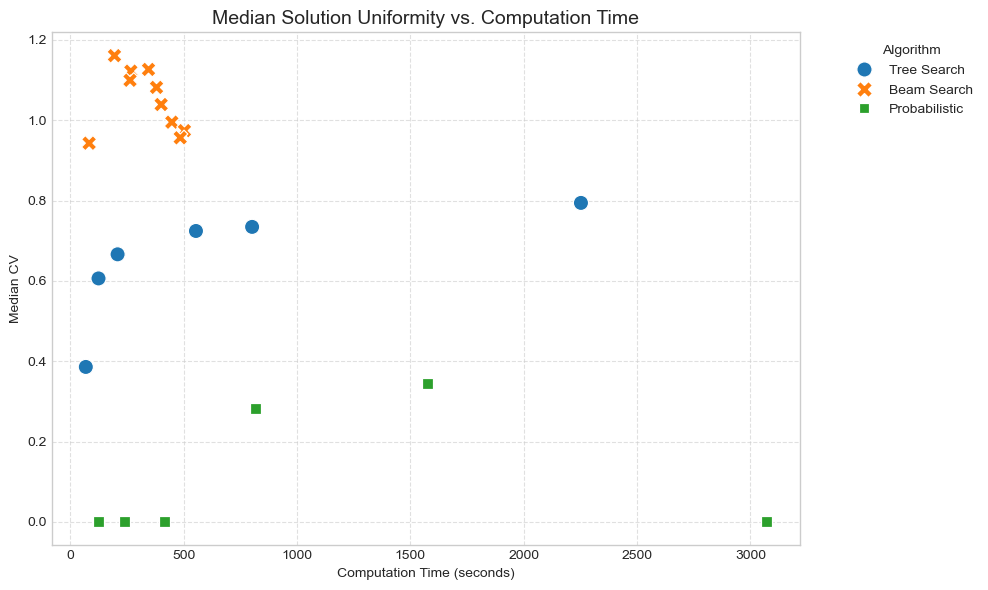

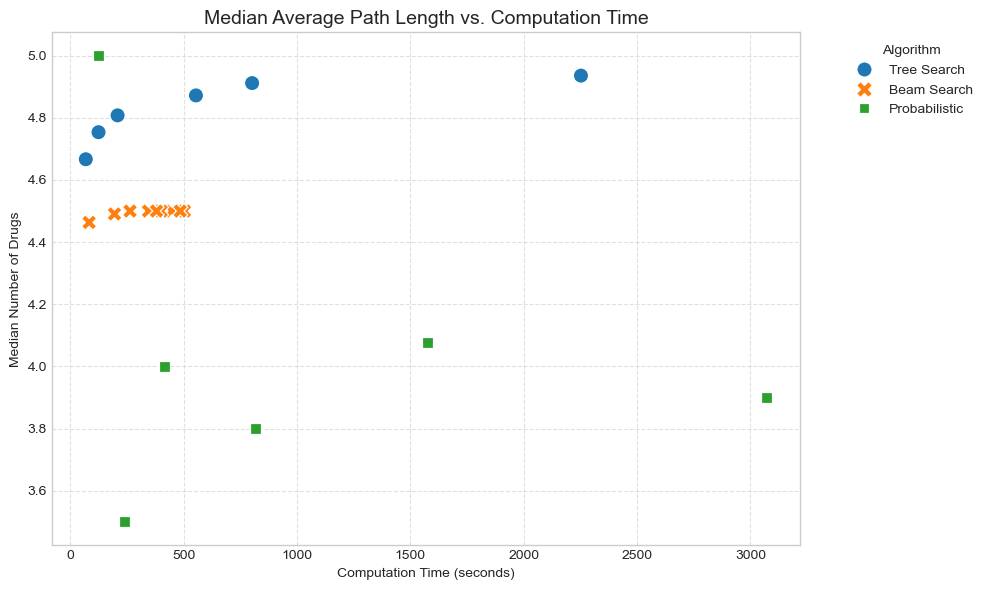

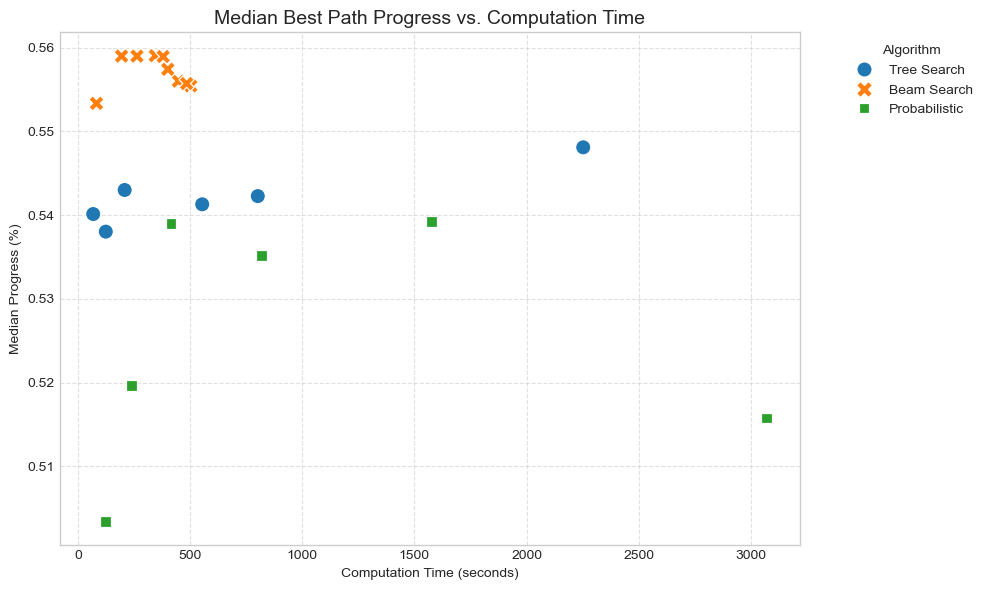

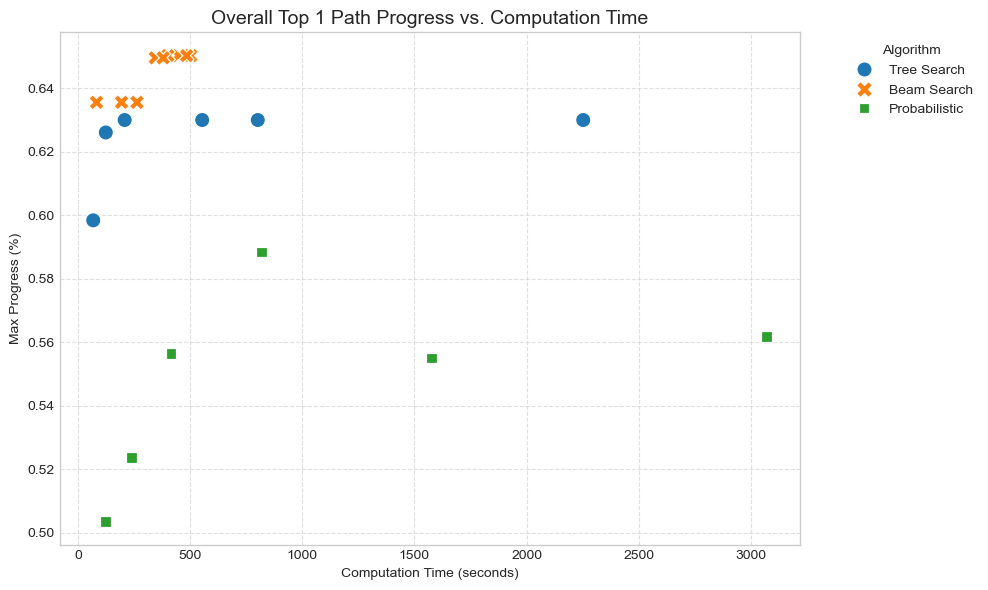

In [11]:
# --- 1. Define the directory where your results are stored ---
results_dir = '../data_and_models/'

# --- 2. Create specific patterns for each algorithm and find the files ---
tree_files = glob.glob(os.path.join(results_dir, 'search_results_tree_k*.pkl'))
beam_files = glob.glob(os.path.join(results_dir, 'search_results_beam_k*.pkl'))
prob_files = glob.glob(os.path.join(results_dir, 'probabilistic_search_results_paths*.pkl'))

# --- 3. Combine the lists into one ---
all_files_to_analyze = tree_files + beam_files + prob_files

# --- 4. Define the path to your timing data ---
times_csv = os.path.join(results_dir, 'algo_times.csv')

# --- 5. Run the comparison analysis ---
if all_files_to_analyze:
    comparison_results = plot_algorithm_efficiency(
        file_paths=all_files_to_analyze,
        times_csv_path=times_csv
    )
else:
    print("No matching result files were found. Check your file patterns.")

Take all metrics or some of them, give it a score of importance and then decide which one is the best. Create a table with the metrics and a check mark the algorithm of the three that is the best in each metric. Use v if it is better vv if it is really better, x if it is worse xx if it is really bad.

create a presentation with just the most important results from the whole thesis, to have it ready for Fabian or future interviews in which I have to expose the whole thing in 15 min. Also include a bit of motivation of why I did this and future directions. Higher level thinking is crucial for phd applications

--- Performance Comparison for Target Cell: CVCL_0292 ---
                                 DQN Search (k=4, n=5)  Tree Search (k=4, n=5)
Total Successful Paths                       20495.000               12348.000
Number of Unique Conversions                    33.000                  27.000
Median Solution Uniqueness                      49.000                  29.000
Median Solution Uniformity (CV)                  0.805                   0.704
Median Path Length                               4.877                   4.810
Median Best Path Progress (%)                   58.015                  55.854
Overall Top 1 Path Progress (%)                 63.696                  62.998
---------------------------------------------------------


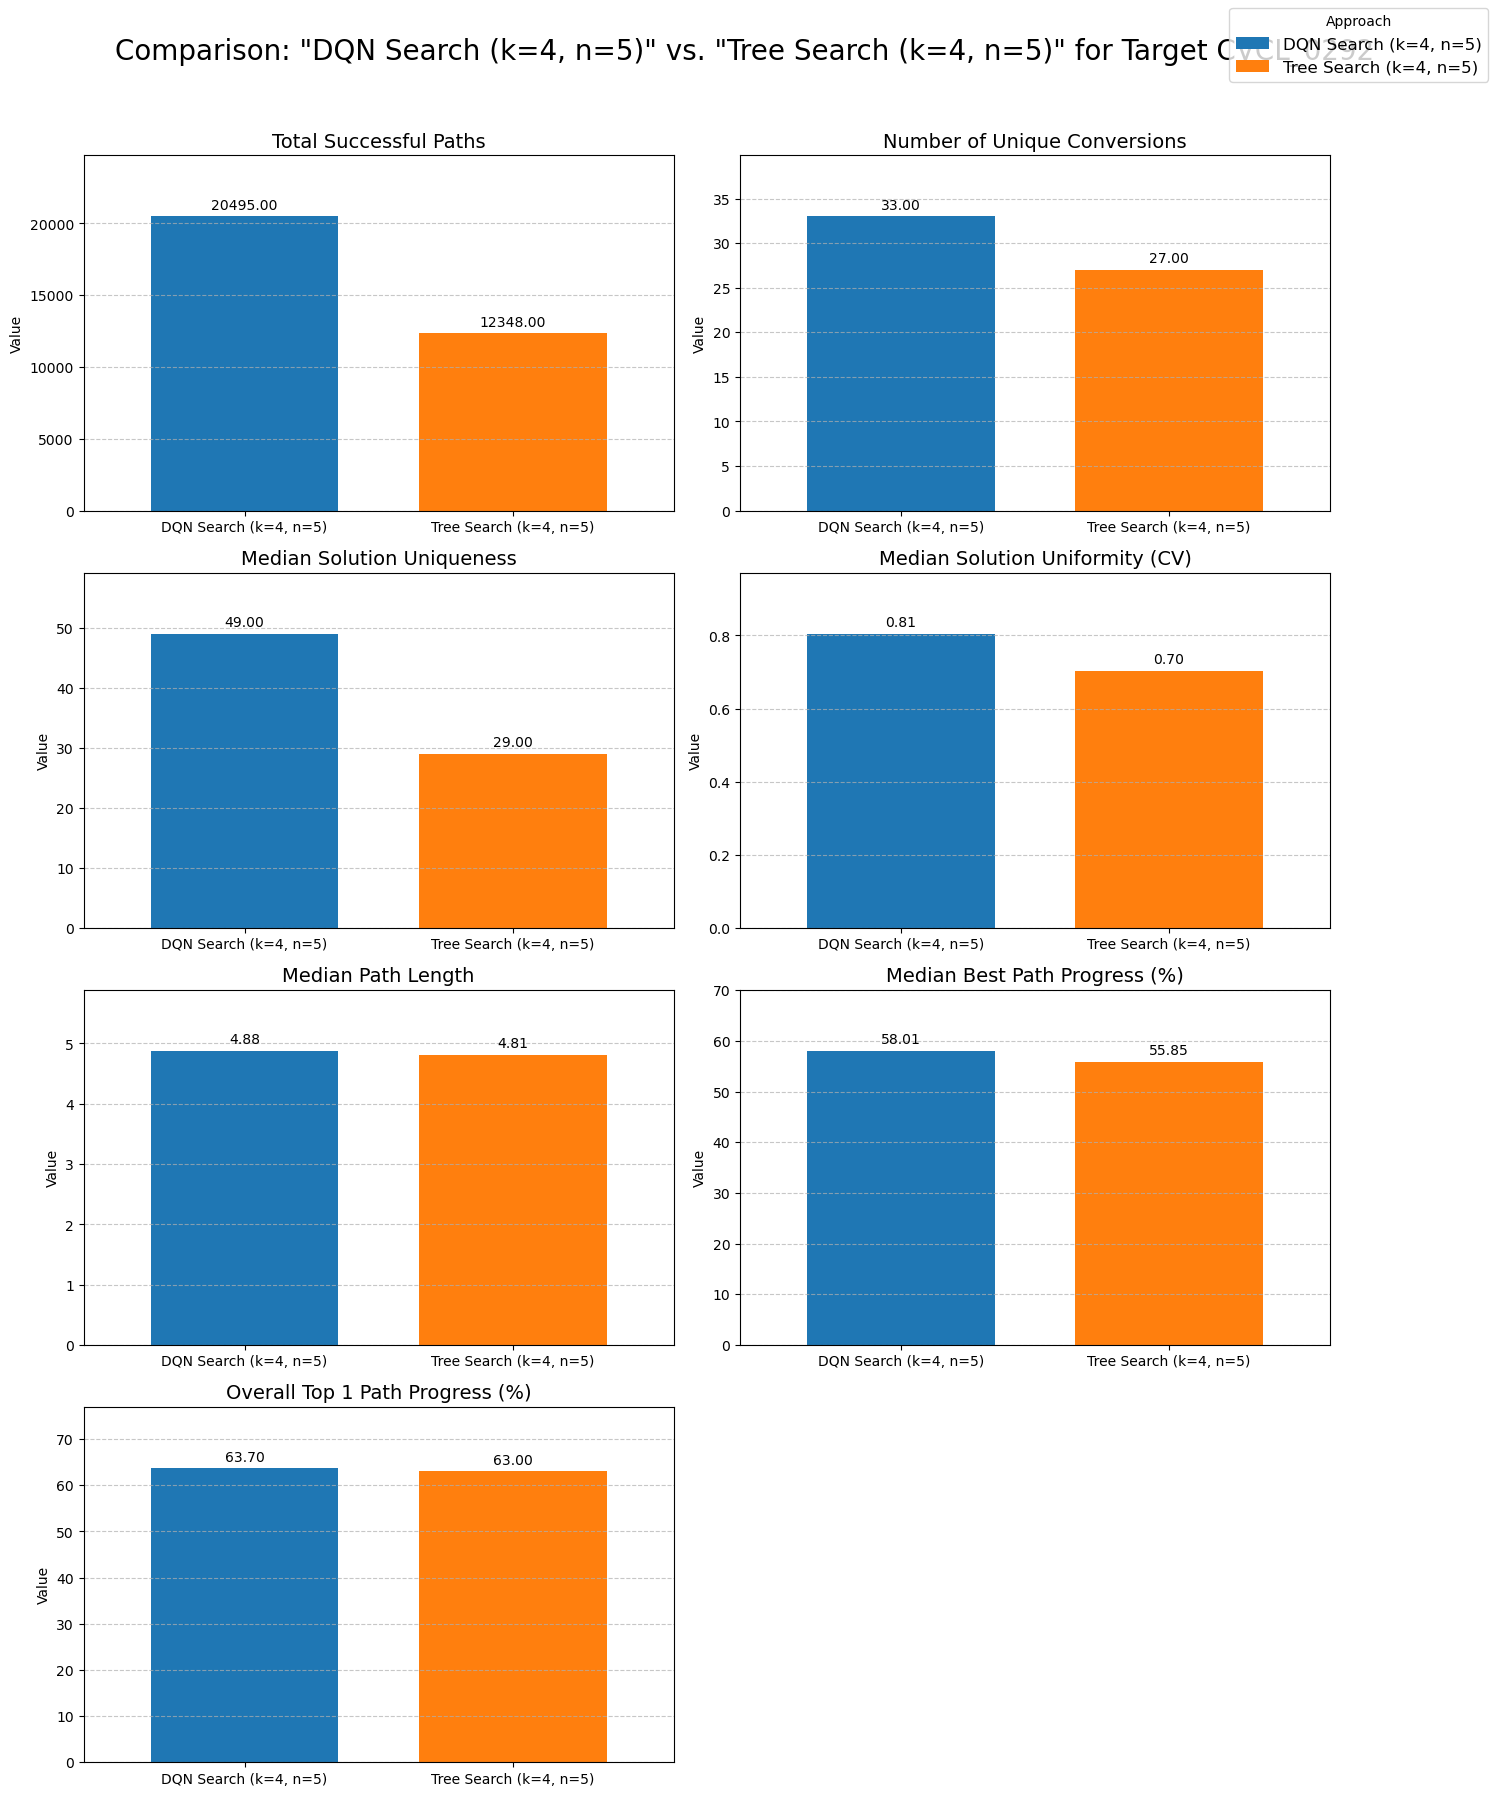

,"DQN Search (k=4, n=5)","Tree Search (k=4, n=5)"
Total Successful Paths,20495.000000,12348.000000
Number of Unique Conversions,33.000000,27.000000
Median Solution Uniqueness,49.000000,29.000000
Median Solution Uniformity (CV),0.805033,0.703873
Median Path Length,4.877221,4.809524
Median Best Path Progress (%),58.014976,55.854287
Overall Top 1 Path Progress (%),63.696016,62.997898


In [2]:
dqn_file = '../data_and_models/dqn_search_results_CVCL_0292_k4_n5_tree_mainrun.pkl'
baseline_file = '../data_and_models/search_results_tree_k4_n5.pkl'
target_cell_id = 'CVCL_0292'

plot_approach_comparison(
    new_approach_file=dqn_file,
    baseline_file=baseline_file,
    target_cell=target_cell_id,
    new_approach_name="DQN Search (k=4, n=5)",
    baseline_name="Tree Search (k=4, n=5)"
)

In [ ]:
# --- 1. Define the directory where your results are stored ---
results_dir = '../data_and_models/'

# --- 2. Define the main comparison files ---
dqn_file = os.path.join(results_dir, 'dqn_search_results_CVCL_0292_k4_n5_tree_mainrun.pkl')
baseline_file = os.path.join(results_dir, 'search_results_tree_k4_n5.pkl')
target_cell_id = 'CVCL_0292'

# --- 4. Find all algorithm files dynamically for summary tables ---
tree_files = glob.glob(os.path.join(results_dir, 'search_results_tree_k*.pkl'))
beam_files = glob.glob(os.path.join(results_dir, 'search_results_beam_k*.pkl'))
prob_files = glob.glob(os.path.join(results_dir, 'probabilistic_search_results_paths*.pkl'))

algo_files = tree_files + beam_files + prob_files

# --- 5. Define the path to your timing data ---
times_file = os.path.join(results_dir, 'algo_times.csv')

print("\n" + "="*50 + "\n") # Separator

# --- 6. Run the summary table generation with the dynamic file list ---
if algo_files and os.path.exists(times_file):
    generate_summary_tables(
        algo_eff_files=algo_files,
        times_csv_path=times_file,
        new_approach_file=dqn_file,
        baseline_file=baseline_file,
        target_cell=target_cell_id,
        new_approach_name="DQN Search (k=4, n=5)",
        baseline_name="Tree Search (k=4, n=5)"
    )
else:
    print("Skipping summary table generation: Could not find algorithm files or the timing CSV.")



--- Generating Table 1: Algorithm Efficiency Summary (Time-Capped) ---


Calculating algo metrics:   0%|          | 0/22 [00:00<?, ?it/s]

Calculating algo metrics: 100%|██████████| 22/22 [05:54<00:00, 16.14s/it]


Time cap set to: 503.68 seconds (min of max times)

Table 1: Algorithm Performance Rating (vs. Average)
                                Beam Search Probabilistic Tree Search
Total Successful Paths                  ✅✅✅           ❌❌❌           ✅
Number of Unique Conversions            ✅✅✅           ❌❌❌          ✅✅
Median Solution Uniqueness              ✅✅✅           ❌❌❌         ✅✅✅
Median Solution Uniformity (CV)         ❌❌❌           ✅✅✅           ❌
Median Path Length                        ❌            ✅✅          ❌❌
Median Best Path Progress (%)             ✅             ❌           ✅
Overall Top 1 Path Progress (%)          ✅✅           ❌❌❌           ✅

--- Generating Table 2: Head-to-Head Summary ---

Table 2: DQN Search (k=4, n=5) Rating (vs. Tree Search (k=4, n=5))
                                DQN Search (k=4, n=5) Tree Search (k=4, n=5)
Total Successful Paths                            ✅✅✅                      -
Number of Unique Conversions                      ✅✅✅           